In [1]:
import numpy as np
import matplotlib.pyplot as plt 
import os 
from pykawa.partial_wave_sums import partial_wave_sum_angular, partial_wave_sum_viscosity, partial_wave_sum_total, partial_wave_sum_momentum

plt.rcParams['axes.linewidth'] = 2.
plt.rcParams['xtick.major.width'] = 2.
plt.rcParams['xtick.major.size'] = 6
plt.rcParams['ytick.major.width'] = 2.0
plt.rcParams['ytick.major.size'] = 6
plt.rcParams['xtick.minor.width'] = 2.
plt.rcParams['xtick.minor.size'] = 4
plt.rcParams['ytick.minor.width'] = 2.
plt.rcParams['ytick.minor.size'] = 4
plt.rcParams.update({'font.size': 16})

### Differential angular dependent, total, momentum, and viscosity transfer cross sections

The following cells use partial wave analysis to compute scattering cross sections for a Yukawa potential
$$V(r) = \alpha_{\chi} \frac{\exp(-r m_{\phi})}{r}$$
for a DM particle of mass $m_{\chi}$, a mediator of mass $m_{\phi}$, and coupling $\alpha$. We use units $\hbar = c = 1$. All cross sections are output in units $\mathrm{cm}^2 \ \mathrm{g}^{-1} \ m_{\chi}^{-3}$ where $m_{\chi}$ is in units GeV. The shape of the cross section depends only on $\alpha$ and $m_{\chi} / m_{\phi}$; to set the overall normalization choose $m_{\chi}$ accordingly.

The following cells compute the scattering cross section per solid angle $d\sigma/d\Omega$, which is given in terms of the partial wave phase shifts $\delta_\ell$ as
$$\frac{d\sigma}{d\Omega} = \frac{1}{k^2} \left| \sum_{\ell=0}^{l_{\rm{max}}} (2\ell+1) e^{i\delta_\ell} \sin\delta_\ell \, P_\ell(\cos\theta) \right|^2$$
where $k = m_\chi v / 2$ is the centre-of-mass momentum and $P_\ell$ are the Legendre polynomials. The total cross section integrated over $d\Omega$ is
$$\sigma_\mathrm{tot} = \int \frac{d\sigma}{d\Omega} \, d\Omega = \frac{4\pi}{k^2} \sum_{\ell=0}^{l_{\rm{max}}} (2\ell+1) \sin^2\delta_\ell$$
The momentum transfer cross section, which weights by the fractional longitudinal momentum transfer $1 - \cos\theta$, is
$$\sigma_\mathrm{T} = \int \frac{d\sigma}{d\Omega} \left(1 - \cos\theta\right) d\Omega = \frac{4\pi}{k^2} \sum_{\ell=0}^{l_{\rm{max}}} (\ell+1) \sin^2(\delta_{\ell+1} - \delta_\ell)$$
The viscosity cross section, which weights by $\sin^2\theta$ and is relevant for the shear viscosity of a DM fluid, is
$$\sigma_\mathrm{V} = \int \frac{d\sigma}{d\Omega} \sin^2\theta \, d\Omega = \frac{4\pi}{k^2} \sum_{\ell=0}^{l_{\rm{max}}} \frac{(\ell+1)(\ell+2)}{2\ell+3} \sin^2(\delta_{\ell+2} - \delta_\ell)$$

The maximum partial wave $l_{\rm{max}}$ is determined adaptively at each velocity by requiring convergence to $1 \%$ over the previous 10 partial waves, and that the value of $\delta_{\ell}$ itself is less than 0.5. Note that the total cross section converges more slowly than the momentum and viscosity transfer cross sections. This may lead to some innaccuray at the level of a few percent at high velocity. 

## Example 1: 

Here we consider an attractive potential with $\alpha = 10^{-2.7}$, $m_{\chi}/m_{\phi}=10^{4.16}$, $m_{\chi}=35 \ \rm{GeV}$

[   1.38229265    1.58562323    1.81886305    2.0859313     2.39276474
    2.74473234    3.14847319    3.61077145    4.14190373    4.75116376
    5.44878912    6.25028758    7.16968376    8.2224265     9.43191764
   10.81932085   12.41080637   14.23311636   16.32675967   18.72837083
   21.47830474   24.63769077   28.2618118    32.41156488   37.17919652
   42.64813065   48.92152651   56.1047976    64.35762368   73.82441258
   84.66423723   97.11806034  111.40379873  127.7614994   146.5547841
  168.11249745  192.84127756  221.15664858  253.68804403  291.00469778
  333.73365131  382.82474332  439.13696902  503.61655744  577.6968507
  662.67410469  760.1512255   871.7661466  1000.        ]


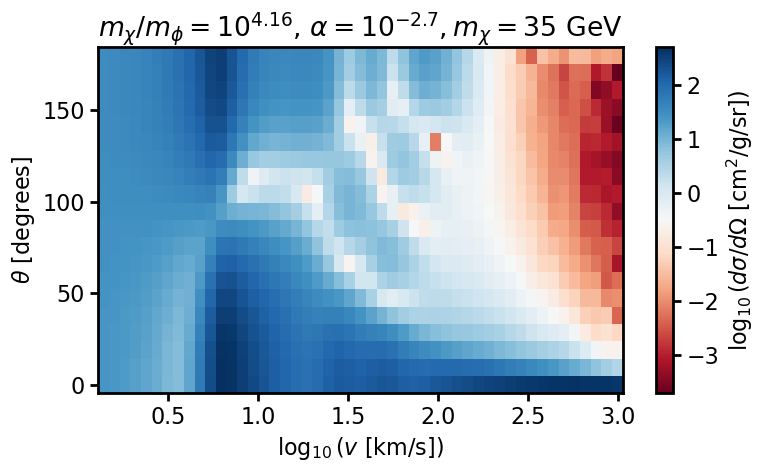

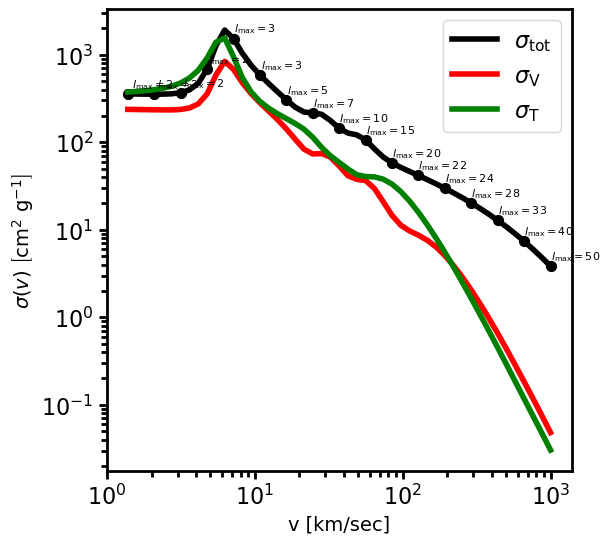

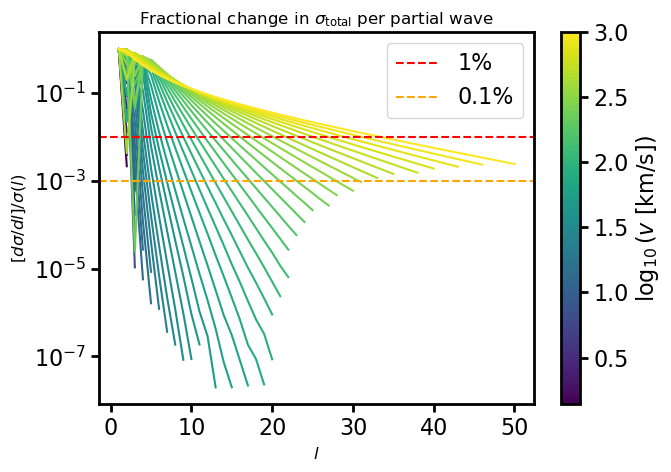

In [10]:
# replace this with the path to the directory where you put the data files
filename = os.getcwd() + '/mphi416_alpha270_phases_highres.txt' # for attractive potential
phase_shift_data = np.loadtxt(filename)
log10_v = phase_shift_data[:,0]
v = 10 ** log10_v
print(v)
phase_shifts = phase_shift_data[:,1:]
theta = np.linspace(0, np.pi, 20)
m_chi_gev = 35
cross_section_angular = partial_wave_sum_angular(10 ** log10_v, theta, phase_shifts) / m_chi_gev ** 3

lmax_array = np.array([np.nonzero(row)[0][-1] for row in phase_shifts])

fig, ax = plt.subplots(figsize=(8, 5))
pm = ax.pcolormesh(
    log10_v,
    np.degrees(theta),
    np.log10(cross_section_angular).T,
    shading='auto',
    cmap='RdBu'
)
plt.colorbar(pm, ax=ax, label=r'$\log_{10}(d\sigma/d\Omega\ [\mathrm{cm}^2/\mathrm{g/sr}])$')
ax.set_xlabel(r'$\log_{10}(v\ [\mathrm{km/s}])$')
ax.set_ylabel(r'$\theta$ [degrees]')
ax.set_title(r'$m_{\chi} / m_{\phi} = 10^{4.16}$, $\alpha = 10^{-2.7}, m_{\chi} = 35 \ \rm{GeV}$')
plt.tight_layout()
plt.show()

cross_section_total = partial_wave_sum_total(10 ** log10_v, phase_shifts)
cross_section_viscosity = partial_wave_sum_viscosity(10 ** log10_v, phase_shifts)
cross_section_momentum = partial_wave_sum_momentum(10 ** log10_v, phase_shifts)

fig = plt.figure(2)
fig.set_size_inches(6,6)
plt.loglog(10**log10_v, cross_section_total / m_chi_gev ** 3, color='k', label=r'$\sigma_{\rm{tot}}$', 
          lw=4)
plt.loglog(10**log10_v, cross_section_viscosity / m_chi_gev ** 3, color='r', label=r'$\sigma_{\rm{V}}$',
          lw=4)
plt.loglog(10**log10_v, cross_section_momentum / m_chi_gev ** 3, color='g', label=r'$\sigma_{\rm{T}}$',
          lw=4)

labels = [lmax_i for lmax_i in lmax_array[0::3]]
plt.scatter(10**log10_v[0::3], cross_section_total[0::3] / m_chi_gev**3, color='k', s=50)
for i, lab in enumerate(labels):
    plt.annotate(r'$l_{\rm{max}}=$'+str(lab), 
                 xy=(10**log10_v[0::3][i]+0.1, 1.2* cross_section_total[0::3][i] / m_chi_gev**3), 
                 color='k', fontsize=8)

plt.xlabel('v [km/sec]', fontsize=14)
plt.ylabel(r'$\sigma\left(v\right) \ \left[\rm{cm^2 \ \rm{g^{-1}}}\right]$', fontsize=14)
plt.legend()
plt.show() 

fig, ax = plt.subplots(figsize=(7, 5))

mask = v > 0
v_sel = v[mask]
log10_v_sel = log10_v[mask]
ph_sel = phase_shifts[mask]
lmax_sel = lmax_array[mask]

cmap = plt.cm.viridis
colors = cmap(np.linspace(0, 1, len(v_sel)))

for j, (vi, ph, lmax) in enumerate(zip(v_sel, ph_sel, lmax_sel)):
    sigma_cumulative = np.array([
        partial_wave_sum_total(np.array([vi]), ph[:L+1].reshape(1, -1))[0]
        for L in range(lmax+1)
    ])
    frac_change = np.diff(sigma_cumulative) / sigma_cumulative[1:]
    ax.semilogy(np.arange(1, lmax+1), frac_change, color=colors[j])

sm = plt.cm.ScalarMappable(cmap=cmap,
     norm=plt.Normalize(vmin=log10_v_sel.min(), vmax=log10_v_sel.max()))
sm.set_array([])
plt.colorbar(sm, ax=ax, label=r'$\log_{10}(v\ [\mathrm{km/s}])$')

ax.axhline(0.01, color='r', ls='--', label='1%')
ax.axhline(0.001, color='orange', ls='--', label='0.1%')
ax.legend()
ax.set_xlabel(r'$l$', fontsize=12)
ax.set_ylabel(r'$[d\sigma/dl] / \sigma(l)$', fontsize=12)
ax.set_title(r'Fractional change in $\sigma_\mathrm{total}$ per partial wave', fontsize=12)
plt.tight_layout()
plt.show()

### Angular dependence 

Here we plot $\frac{d \sigma}{d \Omega}$ as a function of $\theta$ at a couple of velocities

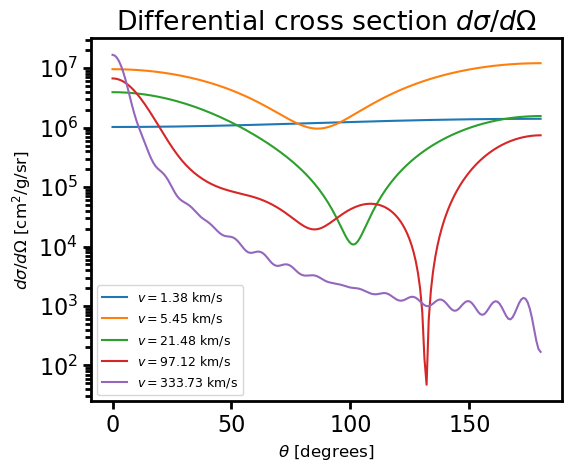

In [19]:
theta = np.linspace(0, np.pi, 200)

# pick a few representative velocities
v_indices = [0, 10, 20, 31, 40]
velocities = np.array([v[i] for i in v_indices])

fig, ax = plt.subplots(figsize=(6, 5))
for i in v_indices:
    dsigma = partial_wave_sum_angular(np.array([v[i]]), theta, phase_shifts[i:i+1])[0]
    ax.semilogy(np.degrees(theta), dsigma, label=f'$v = {{{v[i]:.2f}}}$ km/s')

ax.set_xlabel(r'$\theta$ [degrees]', fontsize=12)
ax.set_ylabel(r'$d\sigma/d\Omega\ [\mathrm{cm}^2/\mathrm{g/sr}]$', fontsize=12)
ax.set_title(r'Differential cross section $d\sigma/d\Omega$')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## Example 2: 

Here we consider a repulsive potential with $\alpha = 10^{-3}$, $m_{\chi}/m_{\phi}=10^{5}$, $m_{\chi}=80 \ \rm{GeV}$

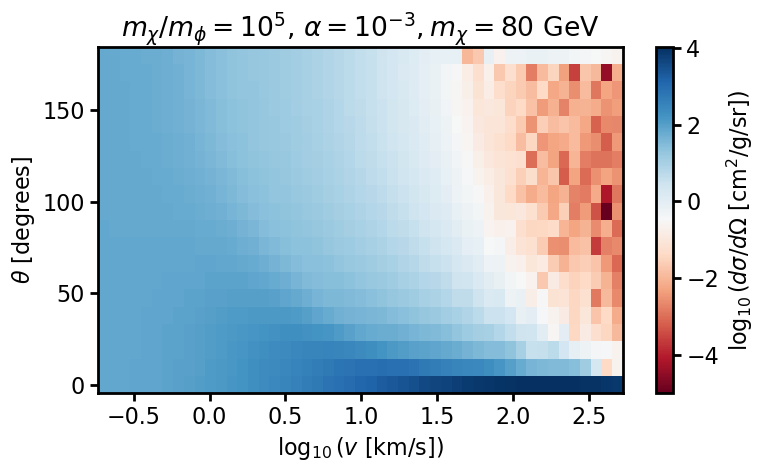

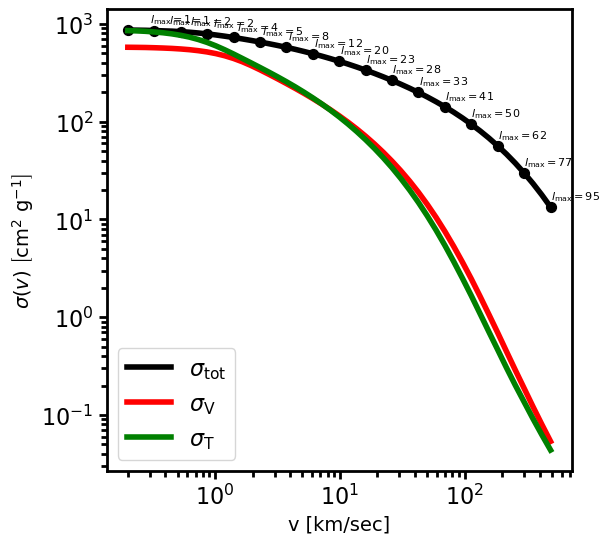

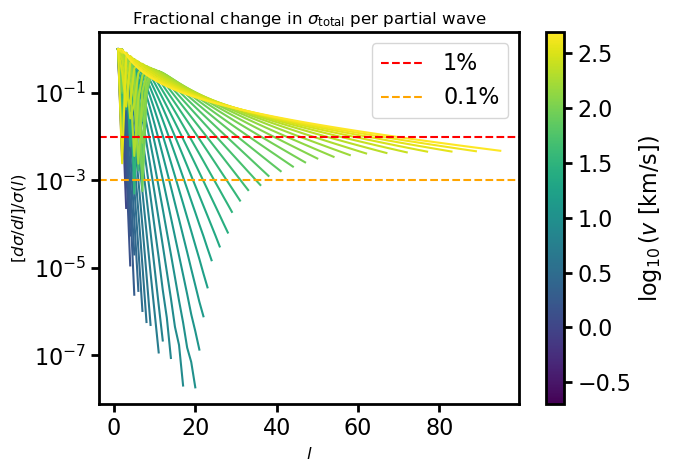

In [20]:
filename = os.getcwd() + '/mphi50_alpha30_phases_highres.txt' # for repulsive potential
phase_shift_data = np.loadtxt(filename)
log10_v = phase_shift_data[:,0]
v = 10 ** log10_v
phase_shifts = phase_shift_data[:,1:]
theta = np.linspace(0, np.pi, 20)
m_chi_gev = 80
cross_section_angular = partial_wave_sum_angular(10 ** log10_v, theta, phase_shifts) / m_chi_gev ** 3

lmax_array = np.array([np.nonzero(row)[0][-1] for row in phase_shifts])

fig, ax = plt.subplots(figsize=(8, 5))
pm = ax.pcolormesh(
    log10_v,
    np.degrees(theta),
    np.log10(cross_section_angular).T,
    shading='auto',
    cmap='RdBu'
)
plt.colorbar(pm, ax=ax, label=r'$\log_{10}(d\sigma/d\Omega\ [\mathrm{cm}^2/\mathrm{g/sr}])$')
ax.set_xlabel(r'$\log_{10}(v\ [\mathrm{km/s}])$')
ax.set_ylabel(r'$\theta$ [degrees]')
ax.set_title(r'$m_{\chi} / m_{\phi} = 10^{5}$, $\alpha = 10^{-3}, m_{\chi} = 80 \ \rm{GeV}$')
plt.tight_layout()
plt.show()

cross_section_total = partial_wave_sum_total(10 ** log10_v, phase_shifts)
cross_section_viscosity = partial_wave_sum_viscosity(10 ** log10_v, phase_shifts)
cross_section_momentum = partial_wave_sum_momentum(10 ** log10_v, phase_shifts)

fig = plt.figure(2)
fig.set_size_inches(6,6)
plt.loglog(10**log10_v, cross_section_total / m_chi_gev ** 3, color='k', label=r'$\sigma_{\rm{tot}}$', 
          lw=4)
plt.loglog(10**log10_v, cross_section_viscosity / m_chi_gev ** 3, color='r', label=r'$\sigma_{\rm{V}}$',
          lw=4)
plt.loglog(10**log10_v, cross_section_momentum / m_chi_gev ** 3, color='g', label=r'$\sigma_{\rm{T}}$',
          lw=4)

labels = [lmax_i for lmax_i in lmax_array[0::3]]
plt.scatter(10**log10_v[0::3], cross_section_total[0::3] / m_chi_gev**3, color='k', s=50)
for i, lab in enumerate(labels):
    plt.annotate(r'$l_{\rm{max}}=$'+str(lab), 
                 xy=(10**log10_v[0::3][i]+0.1, 1.2* cross_section_total[0::3][i] / m_chi_gev**3), 
                 color='k', fontsize=8)

plt.xlabel('v [km/sec]', fontsize=14)
plt.ylabel(r'$\sigma\left(v\right) \ \left[\rm{cm^2 \ \rm{g^{-1}}}\right]$', fontsize=14)
plt.legend()
plt.show() 

fig, ax = plt.subplots(figsize=(7, 5))

mask = v > 0
v_sel = v[mask]
log10_v_sel = log10_v[mask]
ph_sel = phase_shifts[mask]
lmax_sel = lmax_array[mask]

cmap = plt.cm.viridis
colors = cmap(np.linspace(0, 1, len(v_sel)))

for j, (vi, ph, lmax) in enumerate(zip(v_sel, ph_sel, lmax_sel)):
    sigma_cumulative = np.array([
        partial_wave_sum_total(np.array([vi]), ph[:L+1].reshape(1, -1))[0]
        for L in range(lmax+1)
    ])
    frac_change = np.diff(sigma_cumulative) / sigma_cumulative[1:]
    ax.semilogy(np.arange(1, lmax+1), frac_change, color=colors[j])

sm = plt.cm.ScalarMappable(cmap=cmap,
     norm=plt.Normalize(vmin=log10_v_sel.min(), vmax=log10_v_sel.max()))
sm.set_array([])
plt.colorbar(sm, ax=ax, label=r'$\log_{10}(v\ [\mathrm{km/s}])$')

ax.axhline(0.01, color='r', ls='--', label='1%')
ax.axhline(0.001, color='orange', ls='--', label='0.1%')
ax.legend()
ax.set_xlabel(r'$l$', fontsize=12)
ax.set_ylabel(r'$[d\sigma/dl] / \sigma(l)$', fontsize=12)
ax.set_title(r'Fractional change in $\sigma_\mathrm{total}$ per partial wave', fontsize=12)
plt.tight_layout()
plt.show()

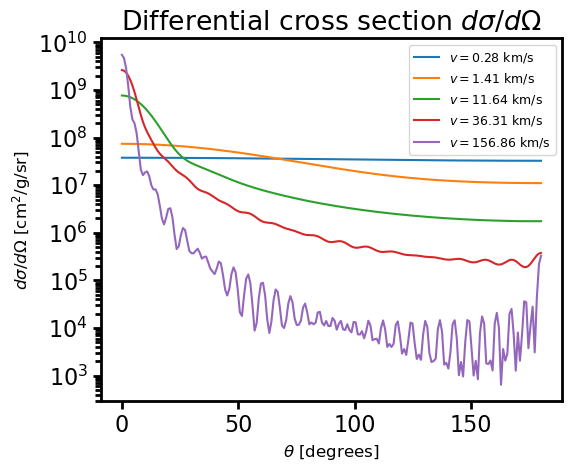

In [22]:
theta = np.linspace(0, np.pi, 200)

# pick a few representative velocities
v_indices = [2, 12, 25, 32, 41]
velocities = np.array([v[i] for i in v_indices])

fig, ax = plt.subplots(figsize=(6, 5))
for i in v_indices:
    dsigma = partial_wave_sum_angular(np.array([v[i]]), theta, phase_shifts[i:i+1])[0]
    ax.semilogy(np.degrees(theta), dsigma, label=f'$v = {{{v[i]:.2f}}}$ km/s')

ax.set_xlabel(r'$\theta$ [degrees]', fontsize=12)
ax.set_ylabel(r'$d\sigma/d\Omega\ [\mathrm{cm}^2/\mathrm{g/sr}]$', fontsize=12)
ax.set_title(r'Differential cross section $d\sigma/d\Omega$')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()